## Lab Exercise Week \#3: Decision Trees in Machine Learning

### Objective:
The goal of this lab exercise is to understand Decision Trees and their application in machine learning. You will apply a decition tree classifier to different datasets and plot the resulting trees.

### Datasets:
For this lab exercise, you'll use the ApplePears, AthleteSelection, Restaurant and Penguins datasets from Brightspace.

### Tasks:

#### 1). Data Loading and Exploration:
<ul>
<li>Import all needed libraries.</li>
<li>Load the ApplePears dataset.</li>
<li>Explore the dataset to understand its structure and features.</li>
<li>Select approprate features for a decision tree.</li>
</ul>

In [ ]:
import pandas as pd # data manipulation , modifyign and explorign dataset
import numpy as np # suport array absed operations
from sklearn import tree # iprot a tree from sklearn - buuilt in class for DT
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt # visualistui of DT
from sklearn.preprocessing import OneHotEncoder # convery categorical data into numeric

In [ ]:
apears = pd.read_csv('ApplesPears.csv') # just path or name of file / for jupyter need path to file
apears.head() # retrieve first 5 rows in the daatset by default head(10) to ge 10 rows...

# df can't deal with categorical features so drop categorical feature taste,,,
# keep other 5 numerical eatures
# 1st thing is to define input and put of model

,Greeness,Height,Width,Taste,Weight,H/W,Class
0,210,60,62,Sweet,186,0.97,Apple
1,220,70,53,Sweet,180,1.32,Pear
2,215,55,50,Tart,152,1.10,Apple
3,180,76,40,Sweet,152,1.90,Pear
4,220,68,45,Sweet,153,1.51,Pear


scikit-learn can deal with a category class label but it cannot deal with categorical features.
So we drop the Taste feature.

See later in the notebook for how to deal with categorical features

In [ ]:
# 1st thing is to define input and put features of model# defnie the clas
y = apears.pop('Class').values
apears.pop('Taste')    # Can't deal with category features - remove taste column 
ap_features = apears.columns # save them into a variable called ap_features
# defien x features of 5 columns....
# converth them into an array using .values
X = apears.values
X[0] # will retrieve the first valeu of the array, the features only

array([210.  ,  60.  ,  62.  , 186.  ,   0.97])

In [22]:
ap_features

Index(['Greeness', 'Height', 'Width', 'Weight', 'H/W'], dtype='object')

In [ ]:
# al the labels we have int he dataset
y

array(['Apple', 'Pear', 'Apple', 'Pear', 'Pear', 'Apple', 'Pear', 'Apple',
       'Apple', 'Apple'], dtype=object)

In [ ]:
apears # the df - taste has been removed, didn't use head so get all rows... that we have inside dataset

,Greeness,Height,Width,Weight,H/W
0,210,60,62,186,0.97
1,220,70,53,180,1.32
2,215,55,50,152,1.10
3,180,76,40,152,1.90
4,220,68,45,153,1.51
5,160,65,68,221,0.96
6,215,63,45,140,1.40
7,180,55,56,154,0.98
8,220,68,65,221,1.05
9,190,60,58,174,1.03


In [ ]:
X # see aray of X - has all values of feature in our dataset

array([[210.  ,  60.  ,  62.  , 186.  ,   0.97],
       [220.  ,  70.  ,  53.  , 180.  ,   1.32],
       [215.  ,  55.  ,  50.  , 152.  ,   1.1 ],
       [180.  ,  76.  ,  40.  , 152.  ,   1.9 ],
       [220.  ,  68.  ,  45.  , 153.  ,   1.51],
       [160.  ,  65.  ,  68.  , 221.  ,   0.96],
       [215.  ,  63.  ,  45.  , 140.  ,   1.4 ],
       [180.  ,  55.  ,  56.  , 154.  ,   0.98],
       [220.  ,  68.  ,  65.  , 221.  ,   1.05],
       [190.  ,  60.  ,  58.  , 174.  ,   1.03]])

#### 2) Decision Tree for Apples and Pears:
<ul>
<li>Create a decision tree classifier.</li>
<li>Train your model.</li>
<li>Predict the outcome.</li>
<li>Plot the decision tree model.</li>
</ul>

Two key methods:
1. `fit` method will train the tree from the data.
2. `predict` method will produce class predictions for an array of test data. 

In [ ]:
# 1st step create an instance of DT classifier... criterion = entropy means we will sue Information Gain (IG)
dtree = DecisionTreeClassifier(criterion='entropy')
# tree it using feature and target... fit mean to train! taring usin features and target
ap_tree = dtree.fit(apears, y)

In [ ]:
# to make sure classifier is trained well we need ot test this classifier with any one of the sample uside of the daatset
# name of tree and .predicyt
# means we will preidict output of sample number 3 in the dataset
ap_tree.predict([X[2]])
# predicts apple correctly
DT classifiers corrcetly based no valuswe have...

c:\Users\eamon\anaconda3\envs\assignment-a\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Apple'], dtype=object)

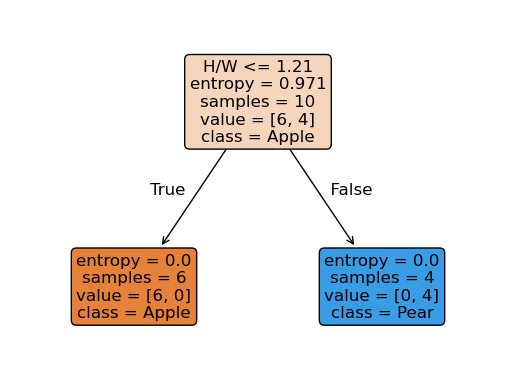

In [ ]:
# next step is to plot this tree
# use mathplotlib + pass nane of tree we have + features name
# font size...class names... fileed = rtue means shapes inside means they will eb filled wiht colours
# shape rounded
tree.plot_tree(ap_tree, feature_names=ap_features, fontsize = 12,
                      class_names=['Apple','Pear'],  
                      filled=True, rounded=True) 
None # supressing the verbose return from plot_tree

# image below represents DT tp clasify apples and pears based on ratino betwene heads and widths
# root node - entropy 0.97 measure impurity >> if closer to one >> less order than clsoer to zero
# sample 1 to 10 > have 10 data points/samples inside the data
# valeus 6 and 4 >>> 6 apples and 4 pears... class is apple as we have a majority apple...
# cassify data bases on height and width
# # Lft = true branch >> entropy = 0 so all belogn to same clas and no chaos
# 6 aples  / 0 pears + no miss classifictio in this branch
# RHS false branch - entropu = 0 >> ni impurity / 4 pears  /0 apples / class pears 
# entropy goes to zero after 1st step >>> no more branches after 1st level split 

#### 3) Decision Tree for Athletes:
<ul>
<li>Load the AthleteSelection.csv dataset</li>
<li>Create a decision tree classifier.</li>
<li>Train your model.</li>
<li>Predict the outcome.</li>
<li>Plot the decision tree model.</li>
</ul>

In [ ]:
# same again but different dataset...
athlete = pd.read_csv('AthleteSelection.csv',index_col = 'Athlete')
athlete.head()

# have 2 features super
# target is selected column

,Speed,Agility,Selected
Athlete,,,
x1,2.50,6.00,No
x2,3.75,8.00,No
x3,2.25,5.50,No
x4,3.25,8.25,No
x5,2.75,7.50,No


In [ ]:
# 1st thing define x and y
# give function name 
# have 2 features + 1 target 
# y is coluimn which is selected and /pop function and name of column
# values means converted into arrary
# thsi one has the labels
y = athlete.pop('Selected').values
# this has numerical features
X = athlete.values

In [ ]:
# 2nd step build our DT using DT classifier
# criteris is the gini >> different to entropy in example 1
# train using x and y and fit

atree = DecisionTreeClassifier(criterion='gini')
atree = atree.fit(X,y)

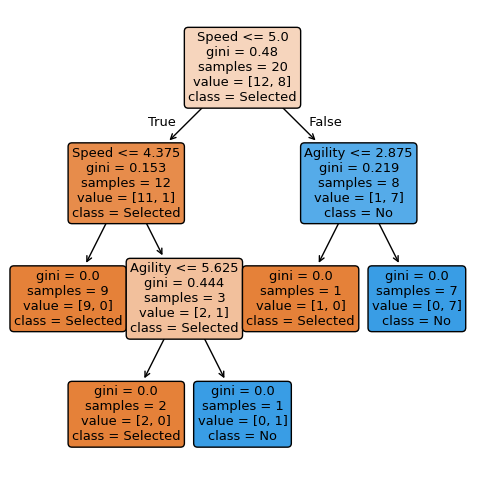

In [ ]:
# 3rd plot
# first plot the tree using plot tr function
# and the anme speed and agility...

fig, ax = plt.subplots(figsize=(6, 6))
tree.plot_tree(atree, feature_names=['Speed','Agility'],  
                      class_names=['Selected','No'],  
                      filled=True, rounded=True,)
None # supressing the verbose return from plot_tree

Run a test example, select one of the training examples

In [ ]:
# top node  = root node -- has speed features < = 5
# gini impurity  -= 0.48
# if gini near zero is better than if gini near 1
# 12 samples is selected and 8 
# Left side = True
# speed become .57 gini 0.15 >> gini decresee >> 11 and 1 = 11 samples classified as selected and just 1 classified as no # mostly seletced class >>> thats why its a selected class
# LEFT >> gini = 0 >> veyr pure node all samples are selected >> 9 classified as selected and zero classified as no
# from RHS > agility is 2nd feature... speed was 1st feature
# gini is 0.44 , number of samples = 3 and clasfiy as ssleted and 1 lassified as not ssleected...
# LHS again >> gini = 0 , gini = pure....
# nuber of samples = 1 and 1 not seletced... no impurity... classifies two classes pergfectly...
# LHS agility < 0.287 >> class selected if nto achieveing these conditions so not seletced...
# class  = no whic means it is nto selectred
 #spli into LHSand RHS - gini = 0 / sample 7 classified as not ssletec >> at thsi level oru rtee becomes perfectyl classiying the two classes...

y_pred = atree.predict([X[5]])
print('Prediced class label:',y_pred[0])

Prediced class label: No


#### 4) Decision Tree for Restaurants:
<ul>
    <li>Import the restaurant.csv dataset</li>
    <li>Use one-hot encoding to deal with categorical features.</li>
<li>Create a decision tree classifier.</li>
<li>Train your model.</li>
<li>Plot the decision tree model.</li>
</ul>

In [ ]:
# test the DT
# use sample nujmber 6 and predicted class is no
# no means abbreviation of number... an index
restaurant = pd.read_csv('restaurant.csv', index_col = 'No')
restaurant.head()

# ;asy column wll wait is class column...
# all otheresare features which will eb x..

,Alternate,Bar,Fri/Sat,Hungry,Patrons,Price,Raining,Reservation,Type,WaitEst,WillWait?
No,,,,,,,,,,,
1,Yes,No,No,Yes,Some,$$$,No,Yes,French,0-10,Yes
2,Yes,No,No,Yes,Full,$,No,No,Thai,30-60,No
3,No,Yes,No,No,Some,$,No,No,Burger,0-10,Yes
4,Yes,No,Yes,Yes,Full,$,No,No,Thai,10-30,Yes
5,Yes,No,Yes,No,Full,$$$,No,Yes,French,>60,No


In [ ]:
# 1st thign define targetg label y . vlaues to amke an array
y = restaurant.pop('WillWait?').values
# define featurs of the model... X
X = restaurant.values
# print and ahve a look at retrieve first 3 rows and all columns....
X[:3,]

# lot of categorical features not numerical...

array([['Yes', 'No', 'No', 'Yes', 'Some', '$$$', 'No', 'Yes', 'French',
        '0-10'],
       ['Yes', 'No', 'No', 'Yes', 'Full', '$', 'No', 'No', 'Thai',
        '30-60'],
       ['No', 'Yes', 'No', 'No', 'Some', '$', 'No', 'No', 'Burger',
        '0-10']], dtype=object)

In [39]:
# get rid of categorical convert to numercoal
# use one hot encoder

# onehot_encoder = OneHotEncoder(sparse=False)  # We can add drop='first'  whcih index column
onehot_encoder = OneHotEncoder(drop='first')  # We can add drop='first'  whcih index column
# all category features converted into numerical features....  
# traing it suign fit
restOH = onehot_encoder.fit(restaurant)
# transform all category features converted into numeric features...
restOH_data = restOH.transform(restaurant)

In [ ]:
# view all clumn names inside the daatset
restaurant.columns

Index(['Alternate', 'Bar', 'Fri/Sat', 'Hungry', 'Patrons', 'Price', 'Raining',
       'Reservation', 'Type', 'WaitEst'],
      dtype='object')

In [41]:
# change th feature names ... columns will ahve yes and no
# use output of OH encoder which gets features name
# this gets the new names....
restOH.get_feature_names_out(restaurant.columns)

array(['Alternate_Yes', 'Bar_Yes', 'Fri/Sat_Yes', 'Hungry_Yes',
       'Patrons_Some', 'Patrons_nan', 'Price_$$', 'Price_$$$',
       'Raining_Yes', 'Reservation_Yes', 'Type_French', 'Type_Italian',
       'Type_Thai', 'WaitEst_10-30', 'WaitEst_30-60', 'WaitEst_>60'],
      dtype=object)

In [ ]:
# this is the number of features now in the dataset
# use name of DF and then get fetaures name  .size gives number of features generated based on OH encodign process...
restOH.get_feature_names_out(restaurant.columns).size

# Add the drop='first' parameter to the encoding and see how many features you end up with 

26

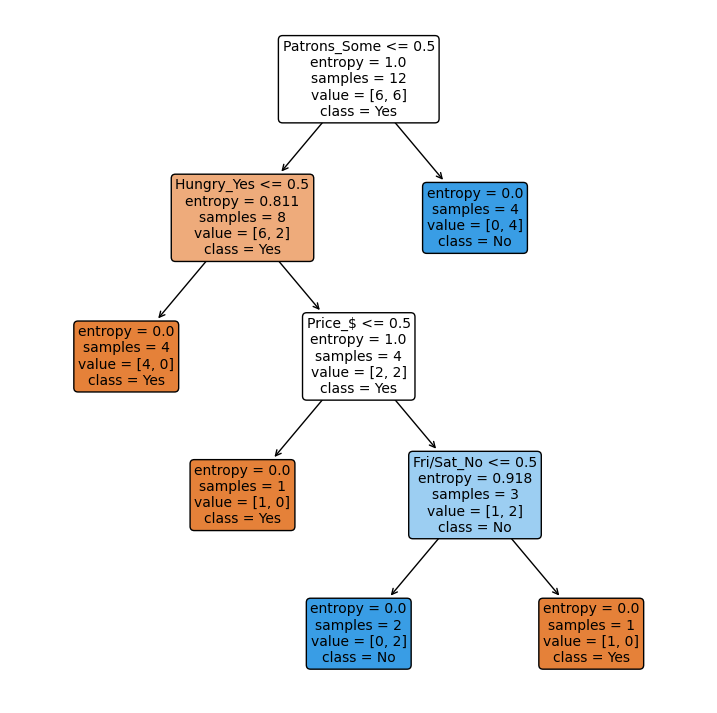

In [ ]:
# build DT
# use entropy which is Information Gain....
rtree = DecisionTreeClassifier(criterion='entropy')
# traing... resrOH is thw featyre set,  target values
rtreeOH = rtree.fit(restOH_data,y)
# plot - make sure using OH encoding names.. not old names
fig, ax = plt.subplots(figsize=(9, 9))
tree.plot_tree(rtreeOH, feature_names=restOH.get_feature_names_out(restaurant.columns),
                        # class  es two  - yes and no
                      class_names=['Yes','No'], fontsize = 10, 
                      filled=True, rounded=True)
None # supressing the verbose return from plot_tree

# plot
# data i split into 6 for yes and 6 for no...
# LHS >> emtrop < 0.811 >>> high impurity..
# number of sampes 6 yes and 2 as no...
# split node again LHS >> entrouy = 0 samples = 4, classified as yes / 0 classified as no >> classified as yes
# very pure as Ebtripy  - 0
# RHS >> <0.5 and entropy =1  = num sample =4 2 yes and 2 = no, need toplsit again
# fri or sat yes... 0.5 entropy 3 samples 1 = yes 2 as no... class will be no....
# LHS zero----
# entropy zero njm of sample = 2
# class is no.. node coems pure... 
# if we go RHS - find entropy  - 0 and samples = 1, 1 sample as yes, zero 0...
# if we go to top LHS entropy  - 0  /4 samples all -clasfified correctly... no impurity.